In [15]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [16]:
# Load test data

X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

In [17]:
# Load trained models

lr = joblib.load("logistic_regression.pkl")
dt = joblib.load("decision_tree.pkl")
rf = joblib.load("random_forest.pkl")
knn = joblib.load("knn.pkl")

In [18]:
# Make predictions

lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
knn_pred = knn.predict(X_test)

In [19]:
# Compare model accuracy

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred)
    ]

})

results

,Model,Accuracy
0,Logistic Regression,0.819730
1,Decision Tree,0.708304
2,Random Forest,0.789922
3,KNN,0.770759


In [20]:
# Best model

best_model = results.loc[results["Accuracy"].idxmax()]

print(best_model)

Model       Logistic Regression
Accuracy                0.81973
Name: 0, dtype: object


In [21]:
# Classification report for Random Forest

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

       False       0.82      0.91      0.86      1036
        True       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



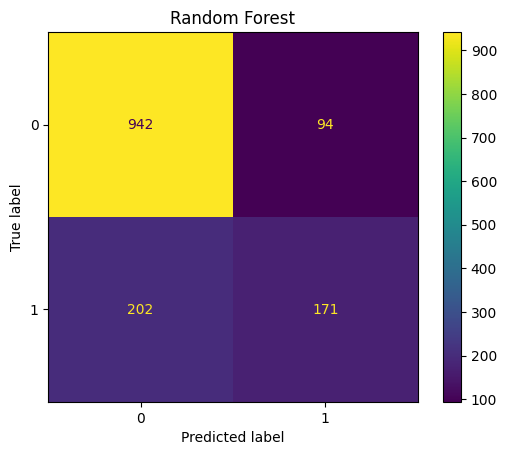

In [22]:
# Confusion matrix

cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("Random Forest")

plt.show()

In [23]:
print("Model evaluation completed.")

Model evaluation completed.
